### Intital Setup
 -- Package import and setuping

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Set plotting styles
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
df = pd.read_csv("../data/benin-malanville.csv", parse_dates=['Timestamp'])

# Quick check
df.head()


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


### Outlier Detection & Basic Cleaning

In [4]:
# Summary stats
df.describe()

# Missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_report[missing_report['Missing %'] > 5])


          Missing Count  Missing %
Comments         525600      100.0


In [5]:
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Replace -1 or negative solar irradiance values with NaN
for col in ['GHI', 'DNI', 'DHI']:
    df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)

# Compute z-scores and flag extreme outliers
df['CleaningFlag'] = False
for col in key_cols:
    col_z = col + '_zscore'
    df[col_z] = zscore(df[col].fillna(df[col].median()))
    df.loc[df[col_z].abs() > 3, 'CleaningFlag'] = True

# Drop z-score columns after flagging
df.drop(columns=[col+'_zscore' for col in key_cols], inplace=True)

# Impute missing values in key columns
for col in key_cols:
    df[col].fillna(df[col].median(), inplace=True)


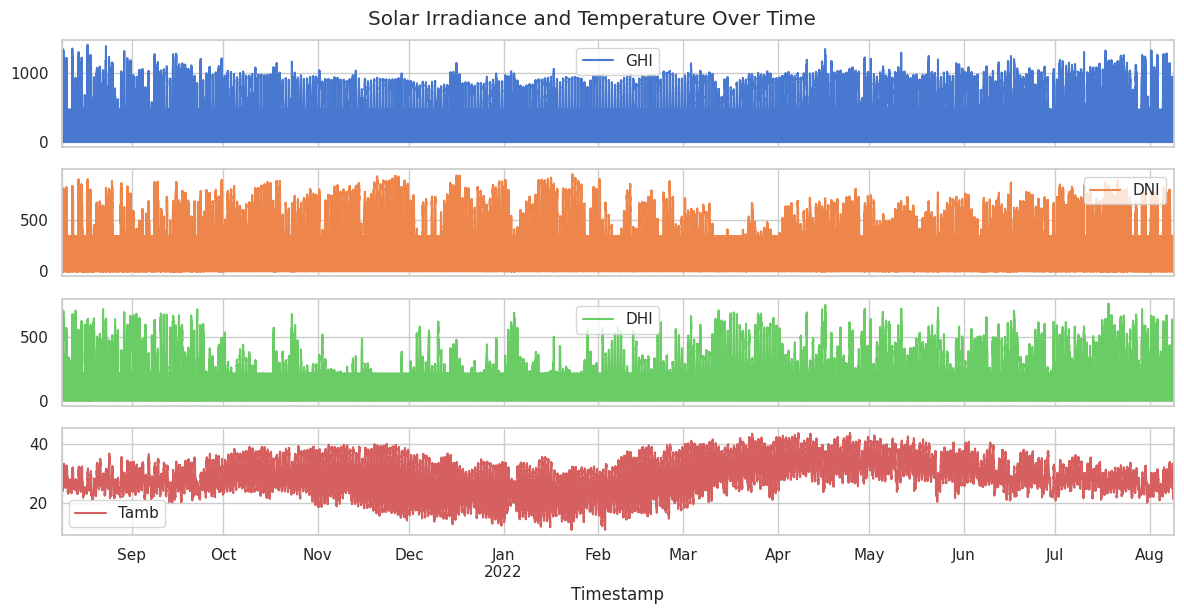

In [6]:
df.set_index('Timestamp')[['GHI', 'DNI', 'DHI', 'Tamb']].plot(subplots=True)
plt.tight_layout()
plt.suptitle("Solar Irradiance and Temperature Over Time", y=1.02)
plt.show()


In [ ]:
### Cleaning Impact

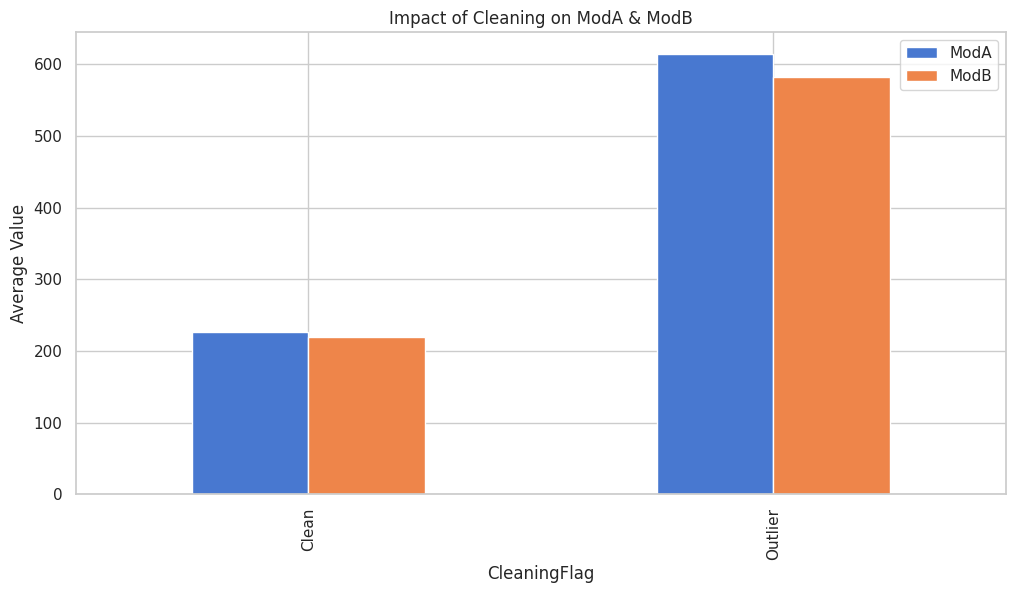

In [7]:
df.groupby('CleaningFlag')[['ModA', 'ModB']].mean().plot(kind='bar')
plt.title("Impact of Cleaning on ModA & ModB")
plt.ylabel("Average Value")
plt.xticks([0, 1], ['Clean', 'Outlier'])
plt.show()


### Temperature Analysis

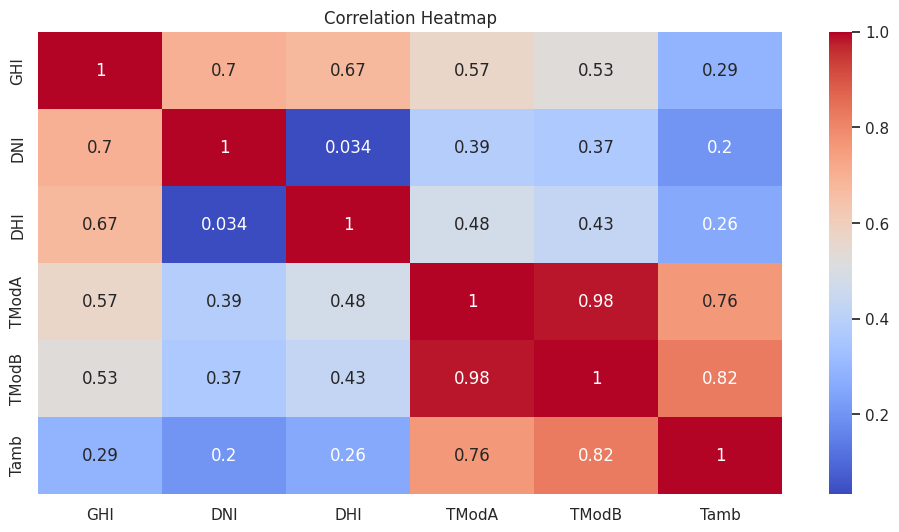

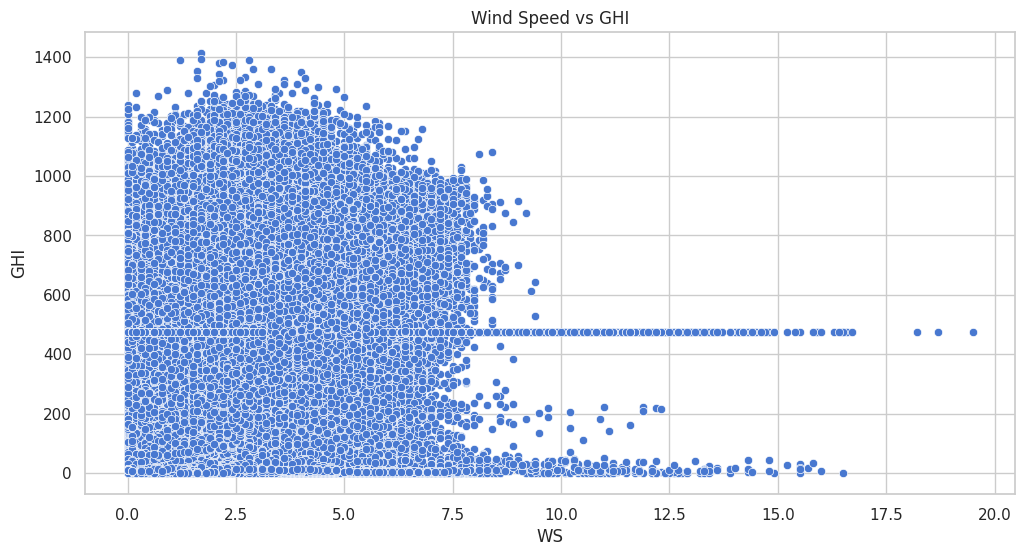

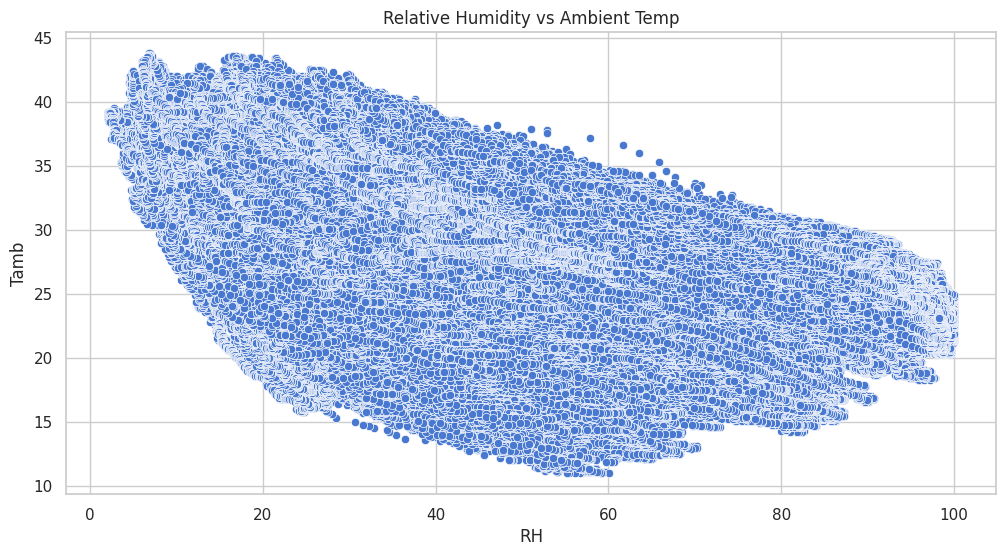

In [8]:
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Wind Speed vs GHI
sns.scatterplot(x='WS', y='GHI', data=df)
plt.title("Wind Speed vs GHI")
plt.show()

# RH vs Tamb
sns.scatterplot(x='RH', y='Tamb', data=df)
plt.title("Relative Humidity vs Ambient Temp")
plt.show()


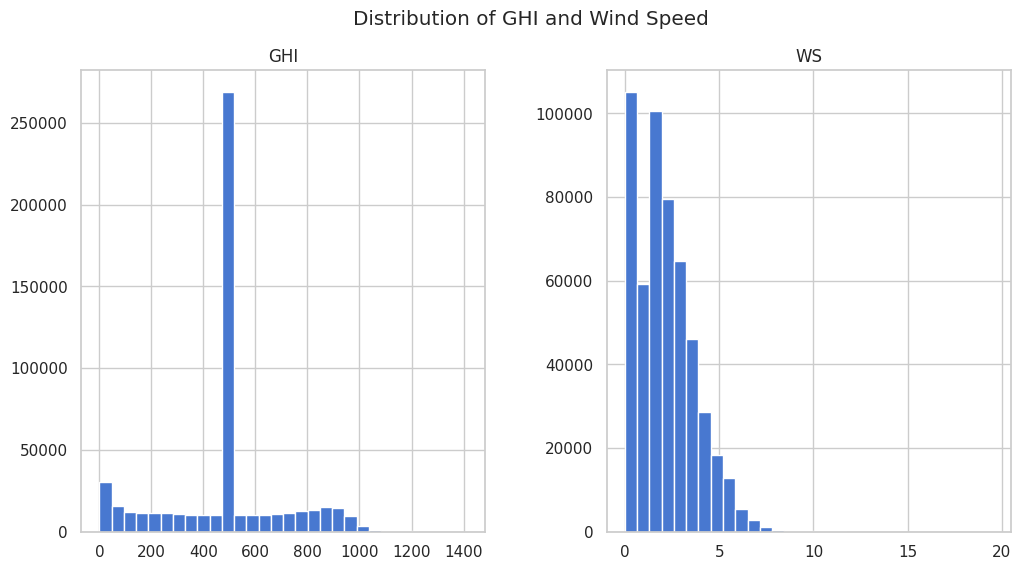

In [9]:
# Histograms
df[['GHI', 'WS']].hist(bins=30)
plt.suptitle("Distribution of GHI and Wind Speed")
plt.show()


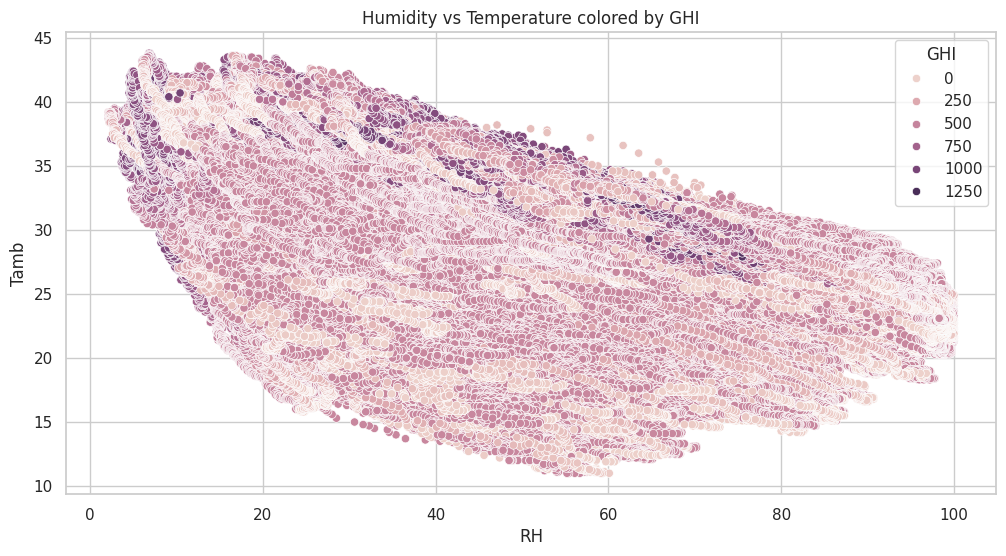

In [10]:
sns.scatterplot(x='RH', y='Tamb', hue='GHI', data=df)
plt.title("Humidity vs Temperature colored by GHI")
plt.show()


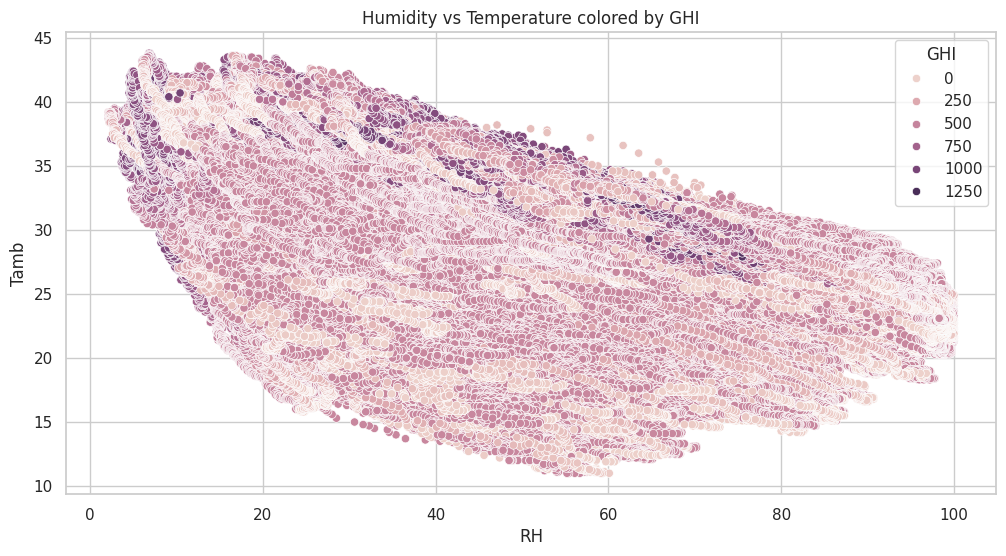

In [11]:
sns.scatterplot(x='RH', y='Tamb', hue='GHI', data=df)
plt.title("Humidity vs Temperature colored by GHI")
plt.show()


### Bubble Chart

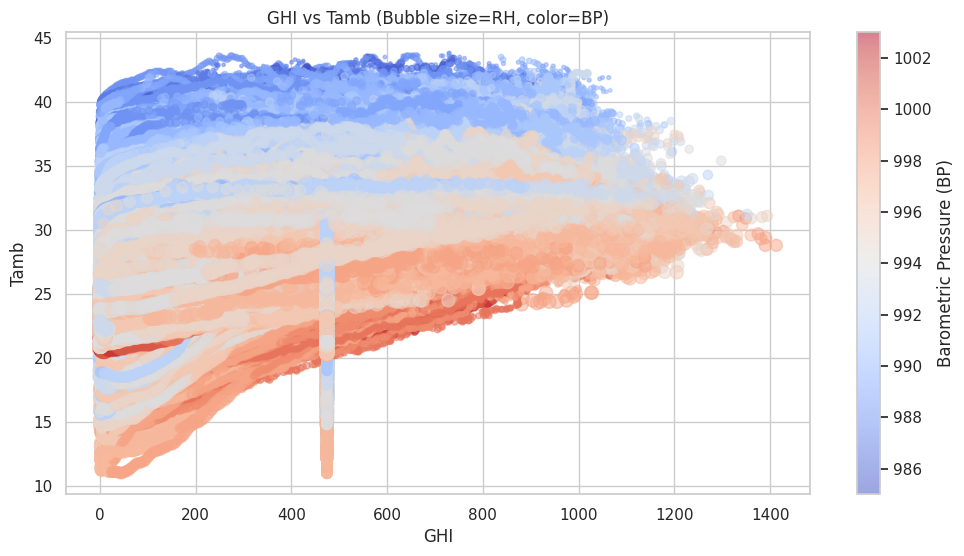

In [12]:
plt.scatter(df['GHI'], df['Tamb'], s=df['RH'], c=df['BP'], cmap='coolwarm', alpha=0.5)
plt.xlabel("GHI")
plt.ylabel("Tamb")
plt.title("GHI vs Tamb (Bubble size=RH, color=BP)")
plt.colorbar(label='Barometric Pressure (BP)')
plt.show()
